### **BANA 780 – Exploratory Data Analysis for Marketing Campaign Response or Customer Personality Analysis Dataset**



Customer Personality Analysis is a detailed analysis of a company’s ideal customers. It helps a business to better understand its customers and makes it easier for them to modify products according to the specific needs, behaviors and concerns of different types of customers.

Customer personality analysis helps a business to modify its product based on its target customers from different types of customer segments. For example, instead of spending money to market a new product to every customer in the company’s database, a company can analyze which customer segment is most likely to buy the product and then market the product only on that particular segment

**Step 1 Notebook Setup**

This analysis uses Python libraries such as pandas for data manipulation and matplotlib/seaborn for data visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

**STEP 2: Load the Dataset**

The dataset contains customer demographic information, purchasing behaviour and marketing campaign response data. Initial inspection shows a mix of numerical and categorical variables suitable for EDA


In [ ]:
df = pd.read_csv("/content/marketing_campaign.csv", sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

**STEP 3: Data Cleaning & Feature Creation**

Missing values were removed to ensure accuracy. Additional variables such as customer age and total spending were derived to enable more meaningful analysis of customer behavior.

In [ ]:
#Check missing values
df.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
#Handle missing values
df = df.dropna()

In [ ]:
# Create Age
df['Age'] = 2024 - df['Year_Birth']

# Create Total Spending
df['Total_Spending'] = (
    df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +
    df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
)

/tmp/ipython-input-2279312711.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age'] = 2024 - df['Year_Birth']
/tmp/ipython-input-2279312711.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Total_Spending'] = (


**STEP 4: “What are the most common values for each variable?”**

Most customers fall within the middle-aged group, indicating the company primarily serves mature consumers rather than very young customers.

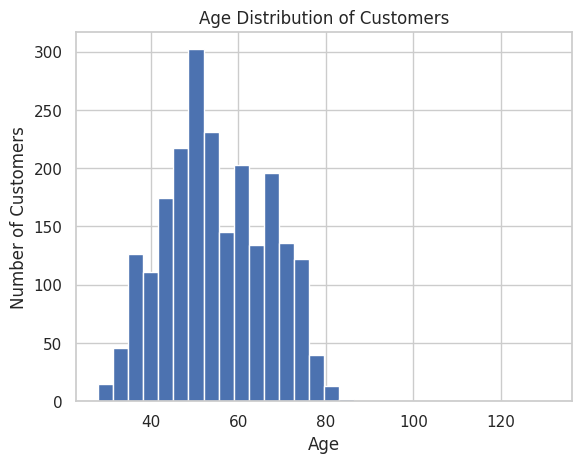

In [ ]:
# Check if 'Age' column exists, and create it if not
# This handles the KeyError by ensuring 'Age' is present in the DataFrame.
if 'Age' not in df.columns:
    df.loc[:, 'Age'] = 2024 - df['Year_Birth']
# Age Distribution
plt.hist(df['Age'], bins=30)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

**Income Distribution**

Customer income varies widely, with a few high-income outliers. These outliers may strongly influence purchasing behavior and marketing response.

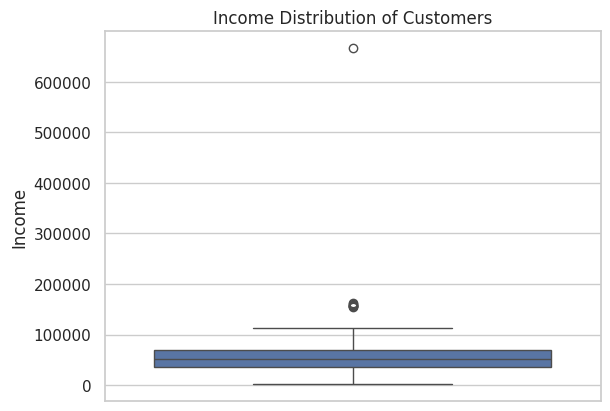

In [ ]:
sns.boxplot(y=df['Income'])
plt.title("Income Distribution of Customers")
plt.show()

**Education Levels**

Customers with higher education levels form the majority of the customer base, suggesting a relatively educated audience.

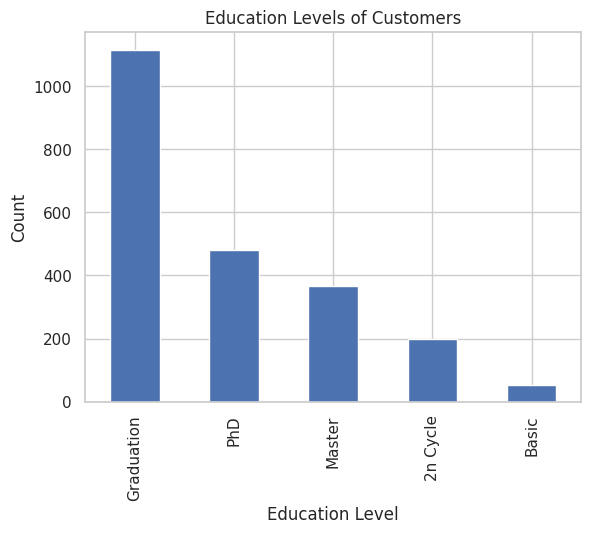

In [ ]:
df['Education'].value_counts().plot(kind='bar')
plt.title("Education Levels of Customers")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.show()

**Step 5: "What type of covariation occurs between variables?**

**Income vs Campaign Response**

Customers who accepted the campaign generally have higher income levels, suggesting income may influence responsiveness to marketing efforts.

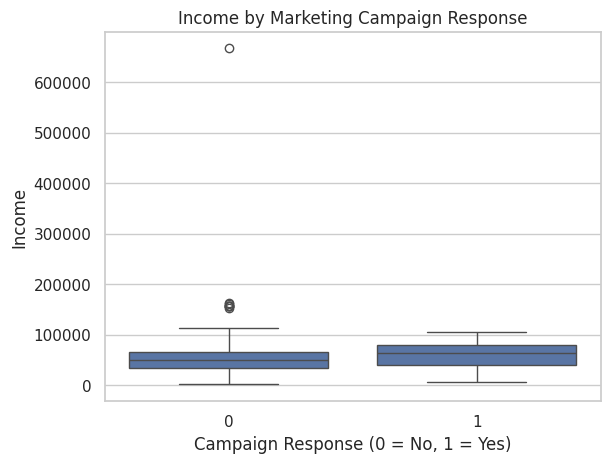

In [ ]:
sns.boxplot(x='Response', y='Income', data=df)
plt.title("Income by Marketing Campaign Response")
plt.xlabel("Campaign Response (0 = No, 1 = Yes)")
plt.show()

**Total Spending vs Campaign Response**

Customers who responded to the campaign tend to spend significantly more overall, indicating that high-value customers are more receptive to marketing initiatives.

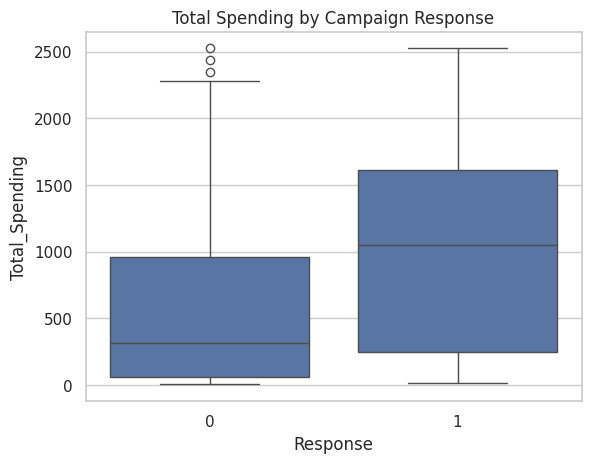

In [ ]:
if 'Total_Spending' not in df.columns:
    df.loc[:, 'Total_Spending'] = (
        df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +
        df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
    )

sns.boxplot(x='Response', y='Total_Spending', data=df)
plt.title("Total Spending by Campaign Response")
plt.show()

**Digital Behavior: Web Visits vs Purchases**

While increased website visits indicate customer engagement, they do not always translate into purchases, highlighting a gap between browsing and buying behavior.

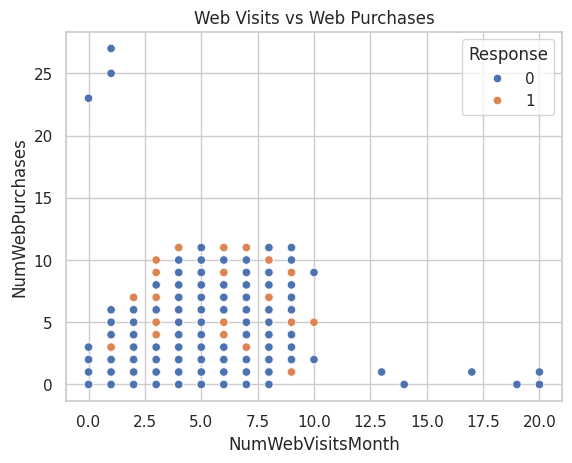

In [ ]:
sns.scatterplot(
    x='NumWebVisitsMonth',
    y='NumWebPurchases',
    hue='Response',
    data=df
)
plt.title("Web Visits vs Web Purchases")
plt.show()

**Correlation Overview**

Total spending and income show the strongest positive relationship with campaign response, supporting their importance for future predictive modeling.

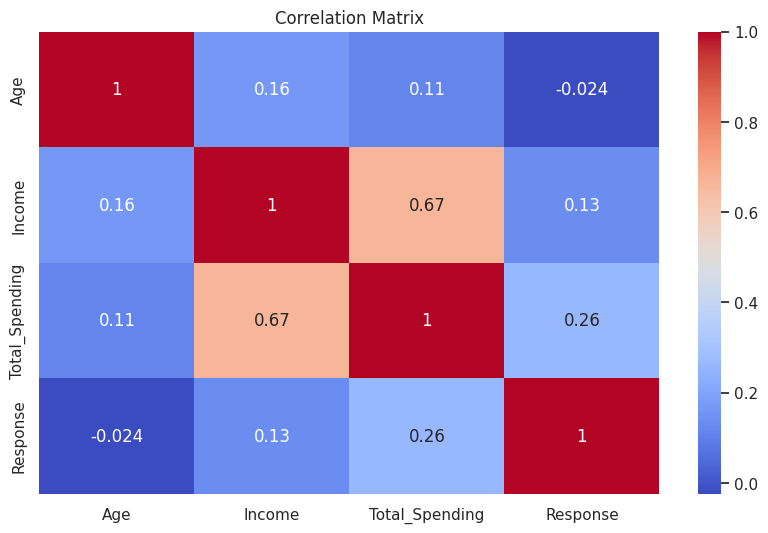

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df[['Age','Income','Total_Spending','Response']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

**Summary**

**Objective:**  
The objective of this analysis was to explore customer demographics and purchasing behavior to identify patterns associated with marketing campaign response.

**Key Findings:**
- Higher-income customers are more likely to respond to campaigns
- Customers with higher total spending show significantly higher response rates
- Digital engagement does not always translate into purchases
- Household structure appears to influence responsiveness

**Surprising Insight:**  
One unexpected finding was that frequent website visits did not consistently lead to higher purchases, suggesting that browsing behavior does not always indicate buying intent.

**Predictive Implications:**  
These insights suggest that campaign response can be predicted using variables such as income, total spending, age, and digital engagement. Classification models such as logistic regression or decision trees could be used in future analysis.
